In [78]:
import pandas as pd 
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [79]:
df= pd.DataFrame()

In [80]:
df['x1'] = [1,2,3,4,5,6,6,7,9,9]
df['x2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0 ]

In [81]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

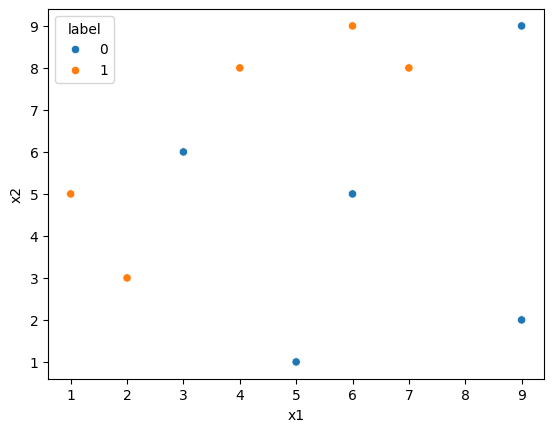

In [82]:
import seaborn as sns

sns.scatterplot(x=df['x1'],y=df['x2'] , hue=df['label'])

In [83]:
df['weights']= 1/df.shape[0]

In [84]:
df.head()

,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1


In [85]:
from sklearn.tree import DecisionTreeClassifier

In [86]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [87]:
x = df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [88]:
dt1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

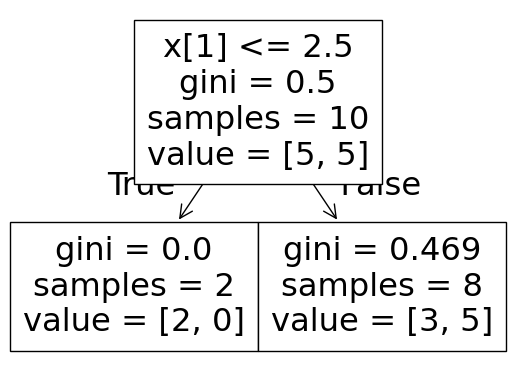

In [89]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

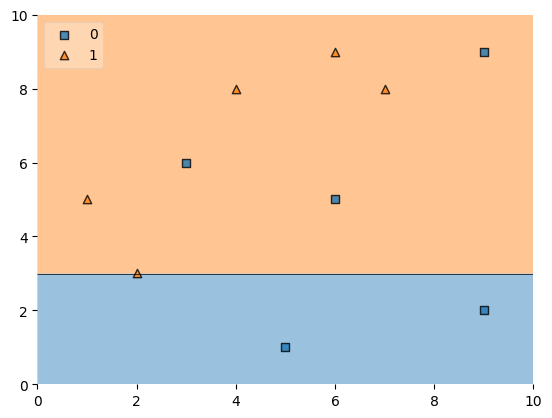

In [90]:
plot_decision_regions(x,y, clf = dt1 , legend=2)

In [91]:
df['y_pred'] = dt1.predict(x)

In [92]:
df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [93]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error + 0.000000001))

In [94]:
alpha1 = calculate_model_weight(0.3)
alpha1

0.42364892852693514

In [95]:
def update_row_weights(row,alpha= 0.42365):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [96]:
df['updated_weights']= df.apply(update_row_weights,axis=1)

In [97]:
df

,x1,x2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,1,0.152753
3,4,8,1,0.1,1,0.065465
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,1,0.065465
6,6,5,0,0.1,1,0.152753
7,7,8,1,0.1,1,0.065465
8,9,9,0,0.1,1,0.152753
9,9,2,0,0.1,0,0.065465


In [98]:
df['normalized']=df['updated_weights']/ df['updated_weights'].sum()

In [99]:
df

,x1,x2,label,weights,y_pred,updated_weights,normalized
0,1,5,1,0.1,1,0.065465,0.071428
1,2,3,1,0.1,1,0.065465,0.071428
2,3,6,0,0.1,1,0.152753,0.166667
3,4,8,1,0.1,1,0.065465,0.071428
4,5,1,0,0.1,0,0.065465,0.071428
5,6,9,1,0.1,1,0.065465,0.071428
6,6,5,0,0.1,1,0.152753,0.166667
7,7,8,1,0.1,1,0.065465,0.071428
8,9,9,0,0.1,1,0.152753,0.166667
9,9,2,0,0.1,0,0.065465,0.071428


In [100]:
df['normalized'].sum()

1.0000000000000002

In [101]:
df['upper'] = np.cumsum(df['normalized'])

In [102]:
df['lower'] = df['upper']-df['normalized']

In [103]:
df

,x1,x2,label,weights,y_pred,updated_weights,normalized,upper,lower
0,1,5,1,0.1,1,0.065465,0.071428,0.071428,0.000000
1,2,3,1,0.1,1,0.065465,0.071428,0.142857,0.071428
2,3,6,0,0.1,1,0.152753,0.166667,0.309524,0.142857
3,4,8,1,0.1,1,0.065465,0.071428,0.380952,0.309524
4,5,1,0,0.1,0,0.065465,0.071428,0.452381,0.380952
5,6,9,1,0.1,1,0.065465,0.071428,0.523809,0.452381
6,6,5,0,0.1,1,0.152753,0.166667,0.690476,0.523809
7,7,8,1,0.1,1,0.065465,0.071428,0.761905,0.690476
8,9,9,0,0.1,1,0.152753,0.166667,0.928572,0.761905
9,9,2,0,0.1,0,0.065465,0.071428,1.000000,0.928572


In [104]:
def create_new_ds(df):
    
    indices = []
    
    for i in range(df.shape[0]):
        
        a = np.random.random()
        for index,row in df.iterrows():
            if row['lower']<a and a<row['upper']:
                indices.append(index)
    return indices

In [105]:
index_values = create_new_ds(df)

In [106]:
index_values

[7, 9, 3, 8, 0, 1, 2, 3, 2, 1]

In [107]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [108]:
second_df

,x1,x2,label,weights
7,7,8,1,0.1
9,9,2,0,0.1
3,4,8,1,0.1
8,9,9,0,0.1
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
2,3,6,0,0.1
1,2,3,1,0.1


In [109]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [110]:
x = second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [111]:
dt2.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.625, 0.5, '  False')]

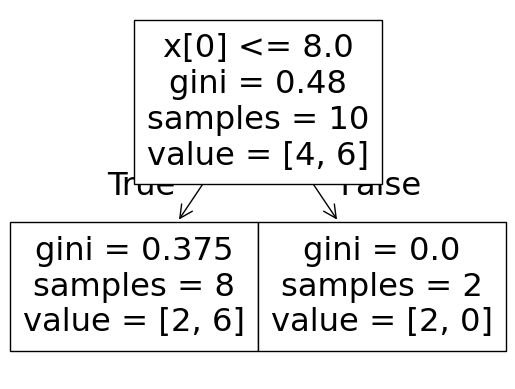

In [112]:
from sklearn.tree import plot_tree
plot_tree(dt2)

<Axes: >

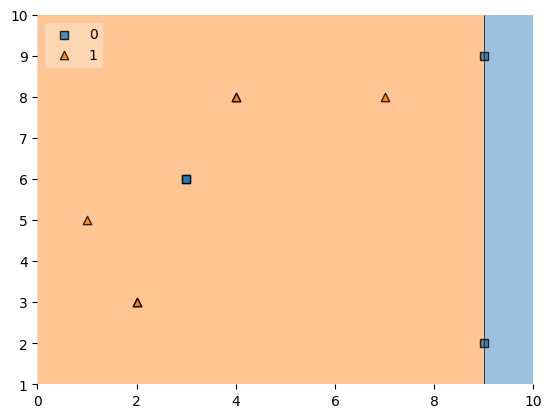

In [113]:
plot_decision_regions(x,y, clf = dt2 , legend=2)

In [114]:
second_df['y_pred'] = dt2.predict(x)

In [115]:
second_df

,x1,x2,label,weights,y_pred
7,7,8,1,0.1,1
9,9,2,0,0.1,0
3,4,8,1,0.1,1
8,9,9,0,0.1,0
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
2,3,6,0,0.1,1
1,2,3,1,0.1,1


In [116]:
alpha2 = calculate_model_weight(0.2)

In [117]:
alpha2

0.6931471780599453

In [118]:
def update_row_weights(row,alpha= alpha2):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [119]:
second_df['updated_weights']= second_df.apply(update_row_weights,axis=1)

In [120]:
second_df

,x1,x2,label,weights,y_pred,updated_weights
7,7,8,1,0.1,1,0.05
9,9,2,0,0.1,0,0.05
3,4,8,1,0.1,1,0.05
8,9,9,0,0.1,0,0.05
0,1,5,1,0.1,1,0.05
1,2,3,1,0.1,1,0.05
2,3,6,0,0.1,1,0.20
3,4,8,1,0.1,1,0.05
2,3,6,0,0.1,1,0.20
1,2,3,1,0.1,1,0.05


In [121]:
second_df['normalized']=second_df['updated_weights']/ second_df['updated_weights'].sum()

In [122]:
second_df

,x1,x2,label,weights,y_pred,updated_weights,normalized
7,7,8,1,0.1,1,0.05,0.0625
9,9,2,0,0.1,0,0.05,0.0625
3,4,8,1,0.1,1,0.05,0.0625
8,9,9,0,0.1,0,0.05,0.0625
0,1,5,1,0.1,1,0.05,0.0625
1,2,3,1,0.1,1,0.05,0.0625
2,3,6,0,0.1,1,0.20,0.2500
3,4,8,1,0.1,1,0.05,0.0625
2,3,6,0,0.1,1,0.20,0.2500
1,2,3,1,0.1,1,0.05,0.0625


In [123]:
df['normalized'].sum()

1.0000000000000002

In [124]:
second_df['upper'] = np.cumsum(second_df['normalized'])
second_df['lower'] = second_df['upper']-second_df['normalized']

In [125]:
second_df

,x1,x2,label,weights,y_pred,updated_weights,normalized,upper,lower
7,7,8,1,0.1,1,0.05,0.0625,0.0625,0.0000
9,9,2,0,0.1,0,0.05,0.0625,0.1250,0.0625
3,4,8,1,0.1,1,0.05,0.0625,0.1875,0.1250
8,9,9,0,0.1,0,0.05,0.0625,0.2500,0.1875
0,1,5,1,0.1,1,0.05,0.0625,0.3125,0.2500
1,2,3,1,0.1,1,0.05,0.0625,0.3750,0.3125
2,3,6,0,0.1,1,0.20,0.2500,0.6250,0.3750
3,4,8,1,0.1,1,0.05,0.0625,0.6875,0.6250
2,3,6,0,0.1,1,0.20,0.2500,0.9375,0.6875
1,2,3,1,0.1,1,0.05,0.0625,1.0000,0.9375


In [126]:
index_values = create_new_ds(second_df)

In [127]:
index_values

[2, 2, 8, 3, 2, 2, 3, 1, 2, 2]

In [128]:
third_df = df.iloc[index_values,[0,1,2,3]]

In [129]:
third_df

,x1,x2,label,weights
2,3,6,0,0.1
2,3,6,0,0.1
8,9,9,0,0.1
3,4,8,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1
3,4,8,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1


[Text(0.5, 0.75, 'x[0] <= 3.5\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.625, 0.5, '  False')]

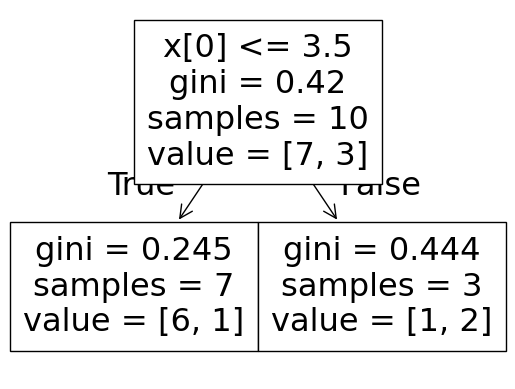

In [131]:
dt3 = DecisionTreeClassifier(max_depth=1)
x = third_df.iloc[:,0:2].values
y=third_df.iloc[:,2].values
dt3.fit(x,y)
from sklearn.tree import plot_tree
plot_tree(dt3)


<Axes: >

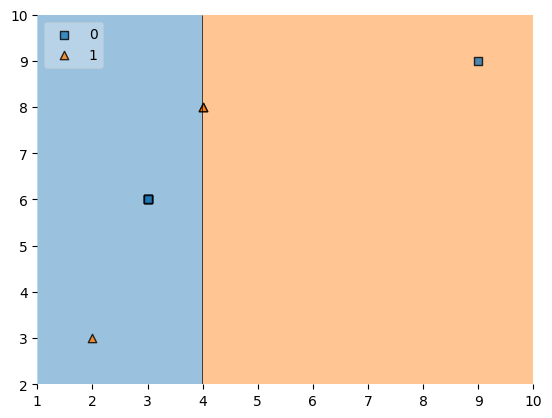

In [132]:
plot_decision_regions(x,y, clf = dt3 , legend=2)

In [133]:
third_df['y_pred'] = dt3.predict(x)


In [134]:
third_df

,x1,x2,label,weights,y_pred
2,3,6,0,0.1,0
2,3,6,0,0.1,0
8,9,9,0,0.1,1
3,4,8,1,0.1,1
2,3,6,0,0.1,0
2,3,6,0,0.1,0
3,4,8,1,0.1,1
1,2,3,1,0.1,0
2,3,6,0,0.1,0
2,3,6,0,0.1,0


In [146]:
alpha3 = calculate_model_weight(0.2)

In [147]:
def update_row_weights(row,alpha= alpha3):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [148]:
third_df['updated_weights']= third_df.apply(update_row_weights,axis=1)
third_df['normalized']=third_df['updated_weights']/ third_df['updated_weights'].sum()
third_df['upper'] = np.cumsum(third_df['normalized'])
third_df['lower'] = third_df['upper']-third_df['normalized']
index_values = create_new_ds(third_df)

In [149]:
index_values

[1, 1, 2, 1, 8, 2, 2, 8, 2, 8]

In [150]:
forth_df = df.iloc[index_values,[0,1,2,3]]

In [143]:
forth_df

,x1,x2,label,weights
1,2,3,1,0.1
2,3,6,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1


In [151]:
query = np.array([1,5]).reshape(1,2)

In [156]:
dt1.predict(query)


array([1])

In [157]:
dt2.predict(query)

array([1])

In [158]:

dt3.predict(query)

array([0])

In [159]:
alpha1*1 + alpha2*1 + alpha3*-1

0.42364892852693525

In [160]:
np.sign(0.42364892852693525)

1.0